Episódio 50/500: score=-187, eps=0.778
Episódio 100/500: score=120, eps=0.606
Episódio 150/500: score=31, eps=0.471
Episódio 200/500: score=222, eps=0.367
Episódio 250/500: score=496, eps=0.286
Episódio 300/500: score=491, eps=0.222
Episódio 350/500: score=338, eps=0.173
Episódio 400/500: score=487, eps=0.135
Episódio 450/500: score=269, eps=0.105
Episódio 500/500: score=200, eps=0.082


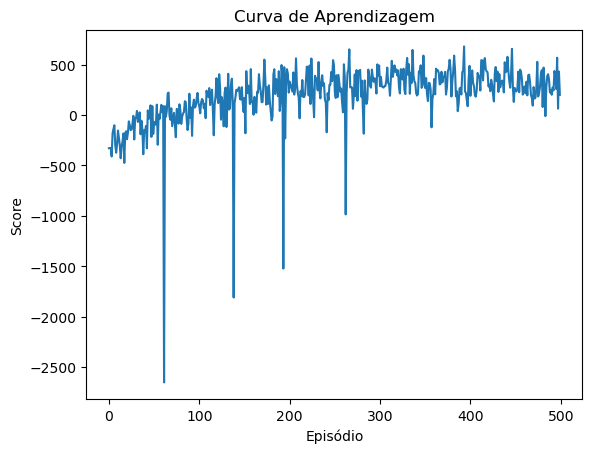


Amostra da política ótima aprendida:
Estado (0, -1, 0, 1, -1) -> AÇÃO: MOVE_E
Estado (0, 0, 0, 1, 1) -> AÇÃO: MOVE_E
Estado (0, 1, 1, 0, -1) -> AÇÃO: MOVE_N
Estado (1, 1, 1, 0, 0) -> AÇÃO: COLLECT_TRASH
Estado (1, 1, -1, 1, 0) -> AÇÃO: MOVE_E


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Definir seed para reprodutibilidade
SEED = 1
random.seed(SEED)
np.random.seed(SEED)

# Constantes do ambiente
GRID_SIZE = 50   # tamanho do grid
TRASH = 1        # lixo
EMPTY = 0        # célula vazia
WALL = -1        # parede

# Mapeamento das ações
ACTIONS = {
    0: "MOVE_N",
    1: "MOVE_S",
    2: "MOVE_E",
    3: "MOVE_W",
    4: "MOVE_RANDOM",
    5: "STAY",
    6: "COLLECT_TRASH"
}
NUM_ACTIONS = len(ACTIONS)

# Recompensas
REWARD_COLLECT_SUCCESS = 10   # ao coletar lixo
REWARD_COLLECT_FAIL    = -1   # coletar onde não há lixo
REWARD_WALL_COLLISION  = -5   # colisão com parede

# Hiperparâmetros do Q-Learning
ALPHA         = 0.1    # taxa de aprendizagem
GAMMA         = 0.9    # fator de desconto
EPSILON_START = 1.0    # epsilon inicial
EPSILON_END   = 0.01   # epsilon mínimo
EPSILON_DECAY = 0.995  # taxa de decaimento do epsilon

NUM_EPISODES = 500   # número de episódios de treino
MAX_STEPS    = 1000  # passos máximos por episódio

class MarvinEnv:
    """
    Ambiente em grade para o robô Marvin coletar lixo.
    Estado: tupla (atual, norte, sul, leste, oeste) cada valor em {-1,0,1}
    """
    def __init__(self, size=GRID_SIZE):
        self.size = size
        self.reset()

    def _generate_grid(self):
        # cria grid vazio
        grid = np.zeros((self.size, self.size), dtype=int)
        # quantidade de lixo e paredes
        n_trash = self.size * self.size // 10
        n_walls = self.size * self.size // 20
        # posiciona lixo e paredes aleatoriamente
        self._random_place(grid, TRASH, n_trash)
        self._random_place(grid, WALL, n_walls)
        # garante que a posição inicial (0,0) esteja vazia
        grid[0,0] = EMPTY
        return grid

    def _random_place(self, grid, value, count):
        # coloca 'count' células com valor 'value' em posições aleatórias
        placed = 0
        while placed < count:
            r = random.randrange(self.size)
            c = random.randrange(self.size)
            if (r, c) != (0,0) and grid[r,c] == EMPTY:
                grid[r,c] = value
                placed += 1

    def reset(self):
        """Reinicia o episódio: gera novo grid e zera posição e score."""
        self.grid = self._generate_grid()
        self.pos   = (0,0)
        self.score = 0
        return self.state()

    def state(self):
        """Retorna o estado atual como uma tupla de 5 valores."""
        r, c = self.pos
        curr  = self.grid[r,c]
        north = self.grid[r-1,c] if r>0             else WALL
        south = self.grid[r+1,c] if r<self.size-1  else WALL
        east  = self.grid[r,c+1] if c<self.size-1  else WALL
        west  = self.grid[r,c-1] if c>0            else WALL
        return (curr, north, south, east, west)

    def step(self, action_idx):
        """
        Executa ação e retorna (próximo_estado, recompensa).
        Não há término antecipado; cada episódio tem passos fixos.
        """
        r, c   = self.pos
        reward = 0

        # ação de coletar lixo
        if action_idx == 6:
            if self.grid[r,c] == TRASH:
                reward = REWARD_COLLECT_SUCCESS
                self.grid[r,c] = EMPTY
            else:
                reward = REWARD_COLLECT_FAIL
            self.score += reward
            return self.state(), reward

        # ações de movimento
        dr, dc = 0, 0
        if action_idx == 0:   dr = -1  # norte
        elif action_idx == 1: dr = +1  # sul
        elif action_idx == 2: dc = +1  # leste
        elif action_idx == 3: dc = -1  # oeste
        elif action_idx == 4:  # movimento aleatório
            candidatos = []
            for ddr, ddc in [(-1,0),(1,0),(0,1),(0,-1)]:
                nr, nc = r+ddr, c+ddc
                if 0 <= nr < self.size and 0 <= nc < self.size:
                    candidatos.append((nr,nc))
            if candidatos:
                nr, nc = random.choice(candidatos)
                dr, dc = nr-r, nc-c

        nr, nc = r+dr, c+dc
        # verifica colisão com parede ou limite
        if not(0 <= nr < self.size and 0 <= nc < self.size) or self.grid[nr,nc] == WALL:
            reward = REWARD_WALL_COLLISION
        else:
            self.pos = (nr, nc)

        self.score += reward
        return self.state(), reward

class QLearningAgent:
    """Agente tabular de Q-Learning com política ε-greedy."""
    def __init__(self, n_actions=NUM_ACTIONS,
                 alpha=ALPHA, gamma=GAMMA,
                 eps_start=EPSILON_START, eps_end=EPSILON_END,
                 eps_decay=EPSILON_DECAY):
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.epsilon   = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.q         = {}  # dicionário: estado -> vetor de Q-valores

    def get_q(self, state):
        # inicializa Q-valores com zero se estado não visitado
        if state not in self.q:
            self.q[state] = np.zeros(self.n_actions)
        return self.q[state]

    def select_action(self, state):
        # escolhe aleatoriamente com probabilidade epsilon
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        # caso contrário, escolhe ação de maior Q-valor (empates aleatórios)
        qs = self.get_q(state)
        max_q = np.max(qs)
        escolhas = np.flatnonzero(qs == max_q)
        return random.choice(escolhas)

    def update(self, s, a, r, s_next):
        # atualiza Q(s,a) com a fórmula do Q-Learning
        q_sa = self.get_q(s)[a]
        q_next_max = np.max(self.get_q(s_next))
        alvo = r + self.gamma * q_next_max
        self.q[s][a] += self.alpha * (alvo - q_sa)

    def decay(self):
        # decai epsilon até o valor mínimo
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

# Utilitários de treinamento e análise

def train(env, agent, episodes=NUM_EPISODES, max_steps=MAX_STEPS):
    """Roda vários episódios de treino e retorna a lista de scores."""
    scores = []
    for ep in range(episodes):
        state = env.reset()
        for _ in range(max_steps):
            action = agent.select_action(state)
            next_state, reward = env.step(action)
            agent.update(state, action, reward, next_state)
            state = next_state
        agent.decay()
        scores.append(env.score)
        if (ep+1) % 50 == 0:
            print(f"Episódio {ep+1}/{episodes}: score={env.score}, eps={agent.epsilon:.3f}")
    return scores

def plot_learning_curve(scores):
    """Plota e salva a curva de aprendizagem."""
    plt.figure()
    plt.plot(scores)
    plt.xlabel('Episódio')
    plt.ylabel('Score')
    plt.title('Curva de Aprendizagem')
    plt.savefig('learning_curve.png')  # salva a imagem
    plt.show()

def extract_optimal_policy(q_table):
    """Retorna dicionário estado -> índice da ação ótima."""
    return {s: int(np.argmax(vals)) for s, vals in q_table.items()}

def display_sample_policy(policy, env, positions=None):
    """Mostra ações ótimas para alguns estados (aleatório ou posições dadas)."""
    estados = list(policy.keys())
    if not positions:
        amostra = random.sample(estados, min(5, len(estados)))
    else:
        amostra = []
        for pos in positions:
            env.pos = pos
            amostra.append(env.state())
    for s in amostra:
        print(f"Estado {s} -> AÇÃO: {ACTIONS[policy[s]]}")

def main():
    # inicializa ambiente e agente
    env   = MarvinEnv()
    agent = QLearningAgent()

    # treina o agente
    scores = train(env, agent)

    # plota e salva curva de aprendizagem
    plot_learning_curve(scores)

    # extrai e mostra uma amostra da política ótima
    policy = extract_optimal_policy(agent.q)
    print("\nAmostra da política ótima aprendida:")
    display_sample_policy(policy, env)

if __name__ == '__main__':
    main()
